In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, integrate
from sklearn import metrics

https://stackoverflow.com/questions/79674833/scipy-optimizewarning-covariance-of-the-parameters-could-not-be-estimated-when

In [2]:
#kb = 1.380649e-23
kb = 8.617333262e-5
B = 0.3808

def model(J, T, N):
    return N * (B * (2 * J + 1) / (kb * T) * np.exp(- B * J * (J + 1)/ (kb * T)))


In [3]:
J = np.array([2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48])
N = np.array([0.185,0.375,0.548,0.695,0.849,0.931,0.996,0.992,1.0,0.977,0.927,0.834,0.691,0.68,0.575,0.479,0.421,0.351,0.259,0.208,0.162,0.135,0.093,0.066])

In [4]:
popt, pcov = optimize.curve_fit(model, J, N, p0=[1e5, 1])
popt, pcov

(array([2.51661517e+06, 2.75770698e+01]),
 array([[1.17518427e+09, 3.25544771e+03],
        [3.25544771e+03, 6.04463335e-02]]))

In [22]:
np.sqrt(np.diag(pcov))

array([3.42809607e+04, 2.45858361e-01])

In [5]:
Nhat = model(J, *popt)
metrics.r2_score(N, Nhat)

0.9940231921241076

In [11]:
Jlin = np.linspace(J.min(), J.max(), 200)
Nlin = model(Jlin, *popt)

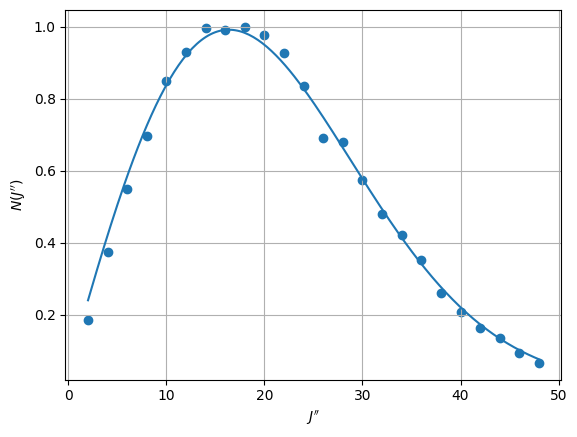

In [12]:
fig, axe = plt.subplots()
axe.scatter(J, N)
axe.plot(Jlin, Nlin)
axe.set_xlabel("$J''$")
axe.set_ylabel("$N(J'')$")
axe.grid()

In [13]:
Jlin = np.linspace(0, 100, 2000)
Nlin = model(Jlin, *popt)

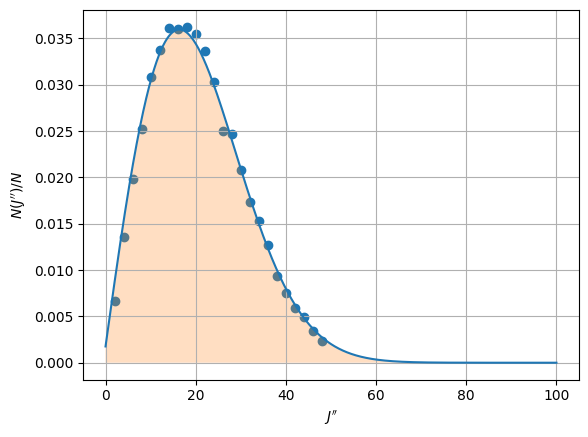

In [17]:
fig, axe = plt.subplots()
axe.scatter(J, N / popt[-1])
axe.plot(Jlin, Nlin / popt[-1])
axe.fill_between(Jlin, Nlin / popt[-1], alpha=0.25)
axe.set_xlabel("$J''$")
axe.set_ylabel("$N(J'')/N$")
axe.grid()

In [21]:
I = integrate.trapezoid(Nlin / popt[-1], Jlin)
I

np.float64(0.9999992484190978)